In [7]:
from topological_insulator import Problem

In [8]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "honeycomb.json"

In [9]:
def _set_eigenvalues(problem:Problem, Delta_SOC, t, delta, U, occupations):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for i, label_i in enumerate(subs):
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        base = i * 8 
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["interaction"][label_i]["U_p"] = U
        parser["interaction"][label_i]["n_px_up"] = occupations[2+base]
        parser["interaction"][label_i]["n_px_down"] = occupations[3+base]
        parser["interaction"][label_i]["n_py_up"] = occupations[4+base]
        parser["interaction"][label_i]["n_py_down"] = occupations[5+base]
        parser["interaction"][label_i]["n_pz_up"] = occupations[6+base]
        parser["interaction"][label_i]["n_pz_down"] = occupations[7+base]
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings  
            try:
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t + delta
            except:
                pass

In [10]:
location = "edge"
N_r = 30

In [11]:
Delta_SOC = -5
t = -1
delta = 0.832

# n_h = 2
x1 = [0.00000000e+00, 0.00000000e+00, 4.37416395e-01, 4.35105678e-01,
       4.35701241e-01, 4.36684426e-01, 6.13836759e-01, 6.12924236e-01,
       9.34237069e-32, 9.53263562e-32, 4.35105678e-01, 4.37416395e-01,
       4.36684426e-01, 4.35701241e-01, 6.12924236e-01, 6.13836759e-01]

x3 = [0.00000000e+00, 0.00000000e+00, 3.30130724e-01, 3.27778991e-01,
       3.28000583e-01, 3.29609775e-01, 5.80717048e-01, 5.79744028e-01,
       4.17340779e-32, 4.29573046e-32, 3.27778991e-01, 3.30130724e-01,
       3.29609775e-01, 3.28000583e-01, 5.79744028e-01, 5.80717048e-01]

    
cases = {
    0: {"U": 1, "x":x1},
    1: {"U": 3, "x":x3}
}

In [12]:
results = {}
for n, U_dict in enumerate(cases.values()):
    U = U_dict["U"]
    x = U_dict["x"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t}, and U/t = {U/t}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    _set_eigenvalues(problem, Delta_SOC, t, delta, U, x)
    problem.setup(
        N_r = N_r,
        N_k = 400,
        location = location,
        BZ = "reduced",
        dangling_bonds=False
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.832, and U/t = -1.0
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832, and U/t = -3.0
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


In [13]:
import numpy as np
edge_sites = [0, 1, 58, 59]
bands = [-1, -2]
a = N_r * 8
b = N_r * 16
j_3_2 = [i for i in range(a, b)]
threshold = 0.12

## Case 0

In [14]:
g = results[0].geometry
tb_edge = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

In [15]:
LDOS_0, E_0 = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 7, 
    E_min = 0.5,
    eta = 0.05
)

LDOS_59, E_59 = invariants.get_local_density_of_states(
    site_idx = 59,
    E_max = 7, 
    E_min = 0.5,
    eta = 0.05
)

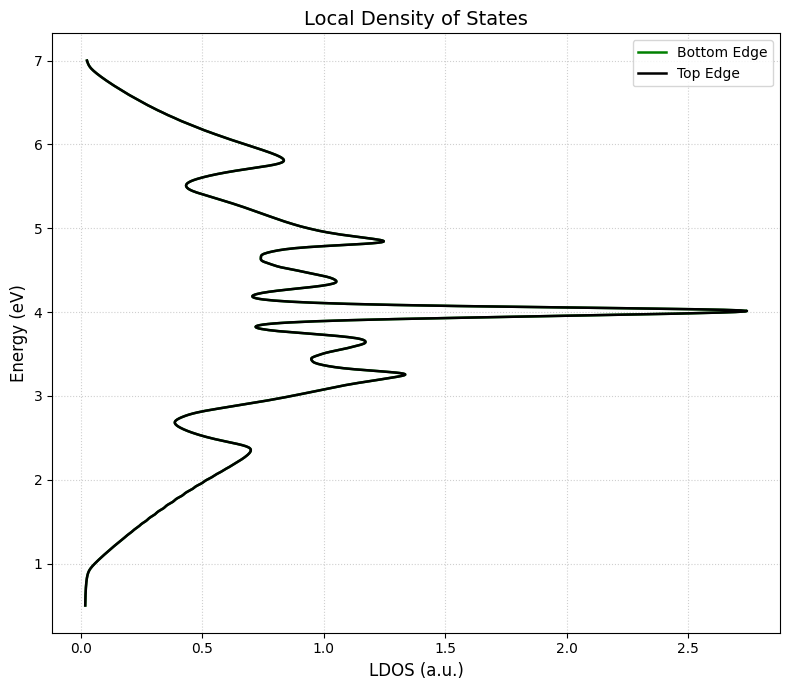

In [16]:
from matplotlib import pyplot as plt
xlabel:str = "LDOS"
figsize: tuple = (8, 7)
fig, ax = plt.subplots(figsize=figsize)
ax.plot(E_0, LDOS_0, color="g", lw=1.8, label=f"Bottom Edge")
ax.plot(E_59, LDOS_59, color="k", lw=1.8, label=f"Top Edge")
ax.set_ylabel("Energy (eV)", fontsize=12)
ax.set_xlabel(f"{xlabel} (a.u.)", fontsize=12)
if xlabel == "LDOS":
    ax.set_title("Local Density of States", fontsize=14)
else:
    ax.set_title("Total Density of States", fontsize=14)
ax.legend(frameon=True)
ax.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

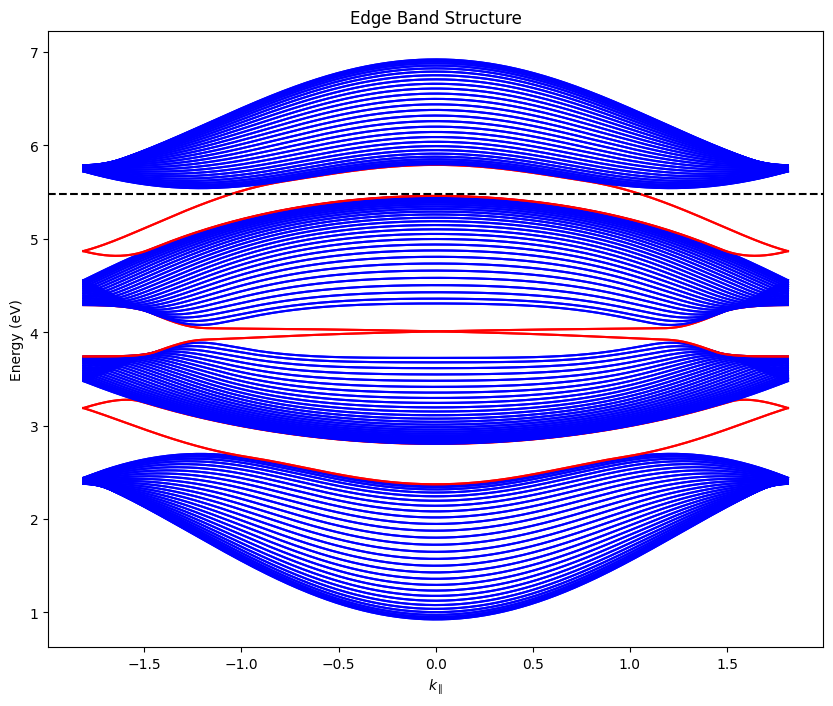

In [17]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-1.7, threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.1, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=1.7, threshold=threshold)
edge_bands_2.append(360)
edge_bands_2.append(358)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands, mu=5.48)

band idx: 298
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  5.23897815e-16+0.00000000e+00j -2.01913756e-02+3.97999122e-03j
 -4.21986620e-01-4.84114760e-01j -5.50117966e-15-3.15739855e-16j
 -1.78769215e-01+3.52643451e-02j -4.16413730e-15+5.56629395e-15j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -5.10789645e-03+2.58812652e-04j  2.17590697e-15-4.03863658e-16j
  1.72499418e-14+2.20153287e-14j  4.52255944e-02-2.28506375e-03j
  2.32537312e-14-3.70005596e-15j  7.25222036e-02-1.42172645e-01j]


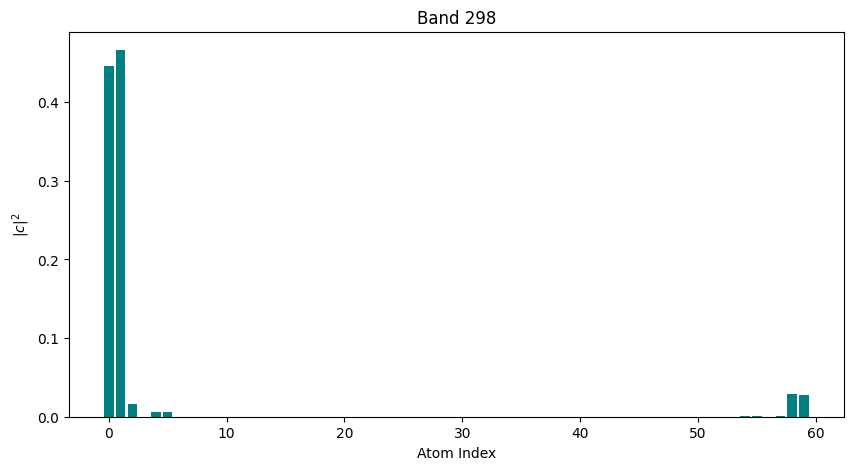

band idx: 299
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -2.27154666e-15+0.00000000e+00j -5.06244792e-03+7.27469042e-04j
 -9.84886858e-02-1.25588653e-01j  2.40600414e-14-4.40673067e-17j
 -4.48219460e-02+6.44740759e-03j  1.38348648e-14-2.43149142e-14j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  2.05798760e-02+2.61487877e-05j  5.46812046e-16-6.90215869e-17j
  4.01125836e-15+5.64571444e-15j -1.82213995e-01-2.57552842e-04j
  5.85058676e-15-6.29056569e-16j -3.21103062e-01+5.56176799e-01j]


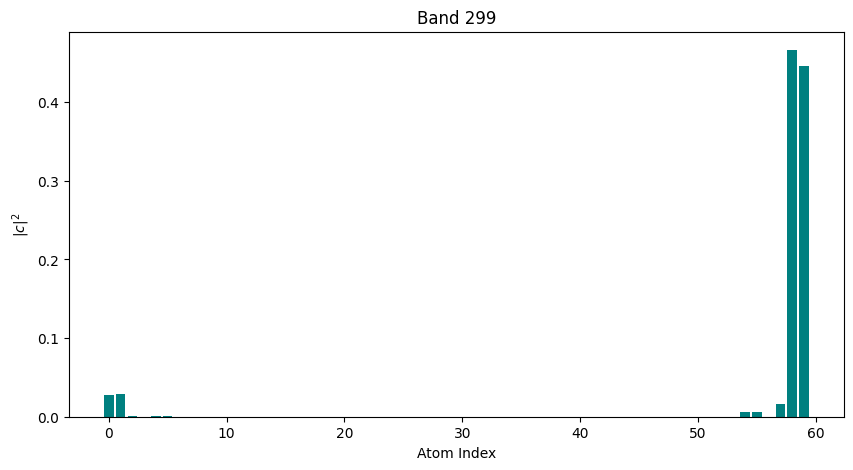

band idx: 300
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -4.12211930e-13+0.00000000e+00j -1.33127121e-12-7.58173574e-12j
  5.67015845e-11-4.74345401e-11j  5.18242733e-12+1.68796445e-16j
 -1.53866493e-11-8.76282295e-11j  3.12796433e-12-5.40553497e-12j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
 -3.67782384e-18-1.98500460e-18j -6.00956485e-03-3.38380186e-02j
  3.98128771e-01-3.35577096e-01j  1.26242540e-16-1.38614949e-17j
 -7.55676235e-02-4.25417082e-01j -1.59301833e-17+4.51953730e-17j]


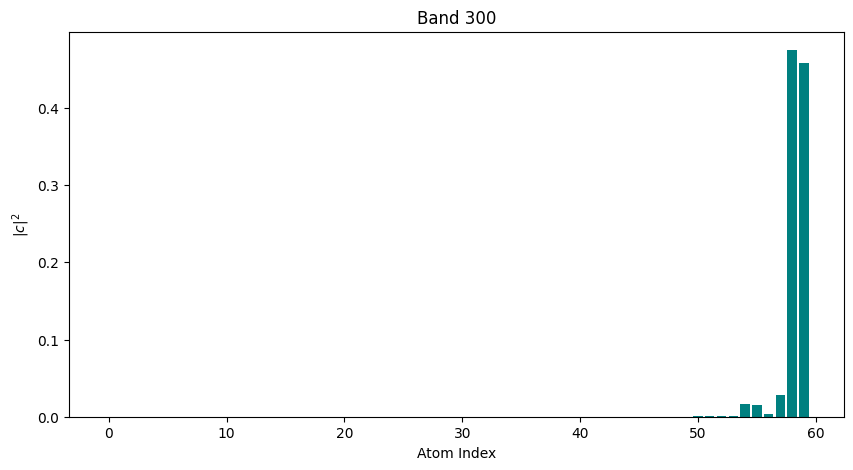

band idx: 301
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -3.43675191e-02+0.00000000e+00j  0.00000000e+00+2.77555756e-17j
 -8.04911693e-16+8.39606162e-16j  4.32076567e-01+1.41733364e-05j
 -1.66533454e-16-8.71403103e-17j  2.60789361e-01-4.50674400e-01j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
 -7.69770961e-12+1.50103325e-14j  7.20801033e-14+4.05860979e-13j
 -4.77524807e-12+4.02498889e-12j  8.89686985e-11-1.73374715e-13j
  9.06375461e-13+5.10255035e-12j  3.67875118e-11-6.41230170e-11j]


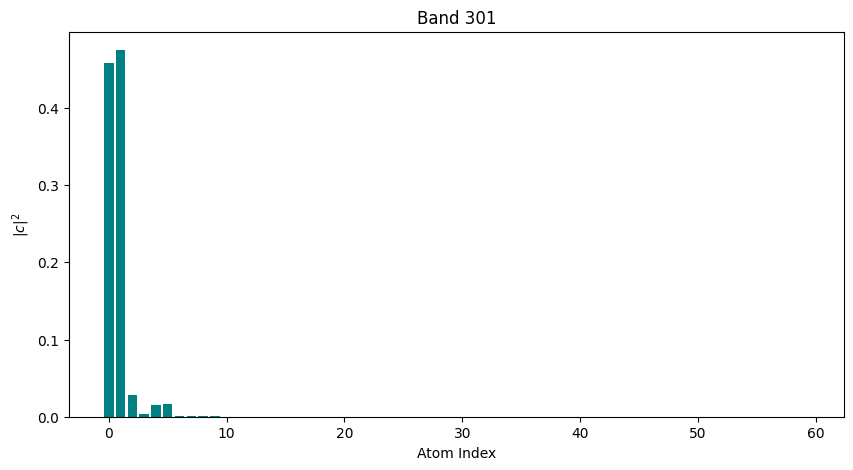

band idx: 358
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -4.35700495e-05+0.00000000e+00j  1.26503226e-04-5.44321452e-05j
  8.66110521e-03+6.47104750e-03j  4.92356080e-03+4.00267791e-06j
  1.38272491e-02-5.93656652e-03j  1.50229096e-03-2.59707245e-03j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  4.94487790e-03+2.81514707e-06j -1.11491129e-06+4.78974945e-07j
 -6.69922072e-05-4.99413174e-05j -5.40307521e-01+1.23120251e-04j
 -1.25944689e-04+5.42281893e-05j -1.94020402e-01+3.36237308e-01j]


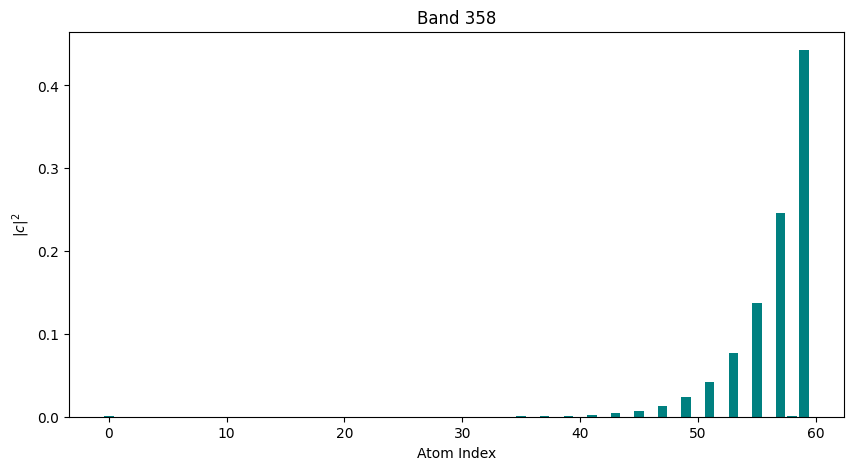

band idx: 359
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  1.21344311e-06+0.00000000e+00j  4.54224163e-03-1.95444783e-03j
  3.10986794e-01+2.32350291e-01j -1.37123116e-04-1.11476160e-07j
  4.96483042e-01-2.13159146e-01j -4.18393973e-05+7.23294950e-05j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -1.37716805e-04-7.84029923e-08j -4.00321529e-05+1.71981380e-05j
 -2.40543109e-03-1.79319957e-03j  1.50477782e-02-3.42894408e-06j
 -4.52218673e-03+1.94712457e-03j  5.40354493e-03-9.36434202e-03j]


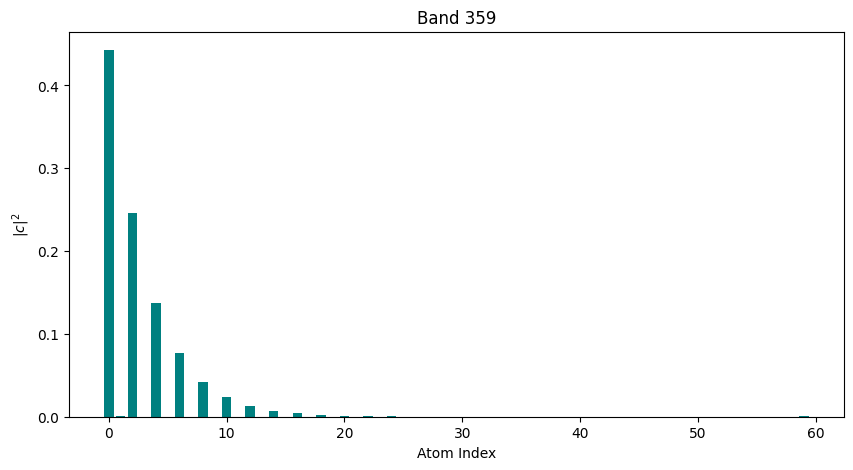

band idx: 360
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  1.18407004e-05+0.00000000e+00j  2.80428558e-05+2.99835048e-05j
 -9.81315120e-04+3.21707279e-03j -1.40057189e-03-1.19267457e-06j
  3.19079909e-03+3.41730352e-03j -4.27959221e-04+7.39770751e-04j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
  1.01185949e-07+7.10735356e-11j  3.27908687e-03+3.51094944e-03j
 -1.00837130e-01+3.31763799e-01j -1.15234889e-05+1.48822823e-09j
  3.88218954e-01+4.14960777e-01j -4.14396325e-06+7.17978831e-06j]


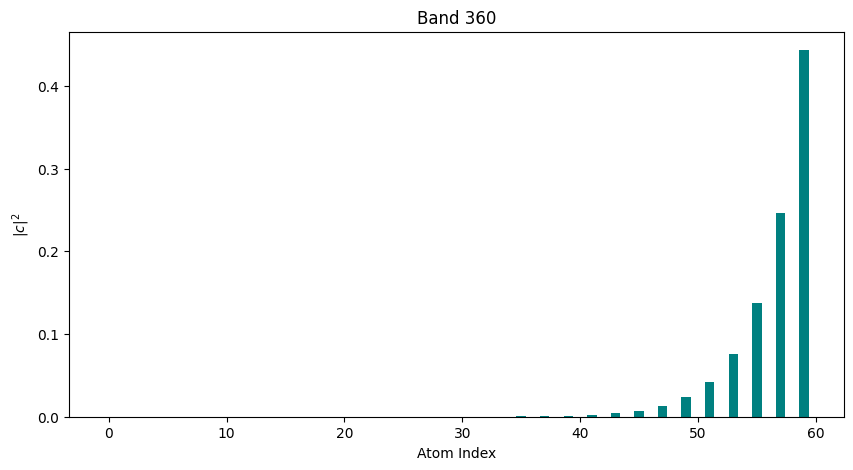

band idx: 361
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  4.80407917e-03+0.00000000e+00j -6.91177314e-08-7.39008840e-08j
  2.41866504e-06-7.92917723e-06j -5.68248334e-01-4.83898997e-04j
 -7.86441997e-06-8.42268950e-06j -1.73634153e-01+3.00144176e-01j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
  4.10537634e-05+2.88363739e-08j -8.08202440e-06-8.65350027e-06j
  2.48535089e-04-8.17704206e-04j -4.67537825e-03+6.03813052e-07j
 -9.56850243e-04-1.02276129e-03j -1.68131334e-03+2.91302629e-03j]


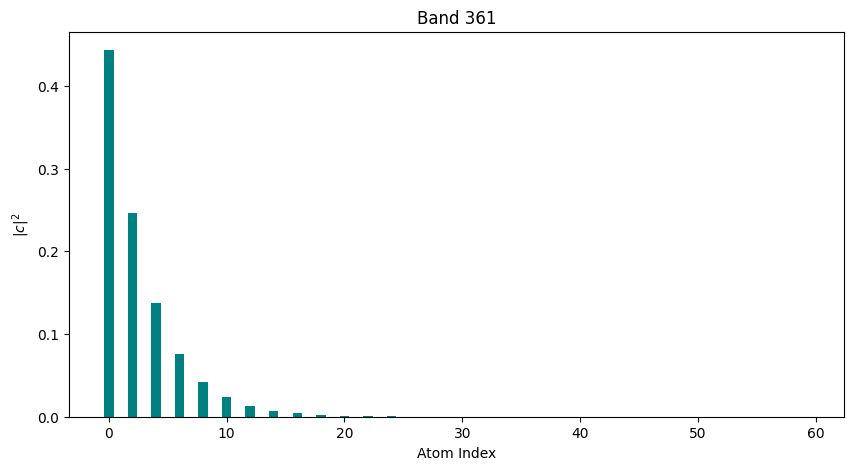

band idx: 418
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  7.58532921e-11+0.00000000e+00j  1.31194960e-12+6.15428676e-12j
  6.29257679e-11-5.68250138e-11j  1.22963173e-09-2.46685865e-14j
 -1.96746052e-11-9.22988311e-11j  5.48144924e-10-9.51487193e-10j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -1.06827362e-17+3.05274371e-18j -6.38840862e-03-3.02414020e-02j
 -3.33176565e-01+2.98670820e-01j -1.70715402e-16+1.69628226e-16j
  1.03550469e-01+4.90235090e-01j -8.07140651e-17-1.45286562e-16j]


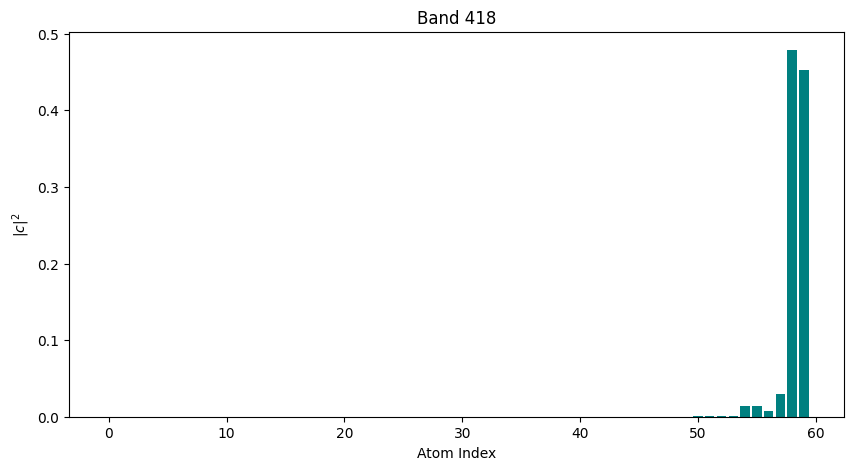

band idx: 419
[0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
 3.09088040e-02+0.00000000e+00j 1.11022302e-16+4.16333634e-17j
 2.41473508e-15-1.23338839e-15j 5.01052036e-01-1.00528676e-05j
 6.10622664e-16-5.86306662e-16j 2.23358895e-01-3.87713407e-01j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -6.29260992e-12-1.14974962e-14j  1.56777928e-11+7.42154211e-11j
  8.17648569e-10-7.32968023e-10j -9.43727768e-11-1.71739590e-13j
 -2.54123192e-10-1.20308587e-09j -4.25903742e-11+7.33133776e-11j]


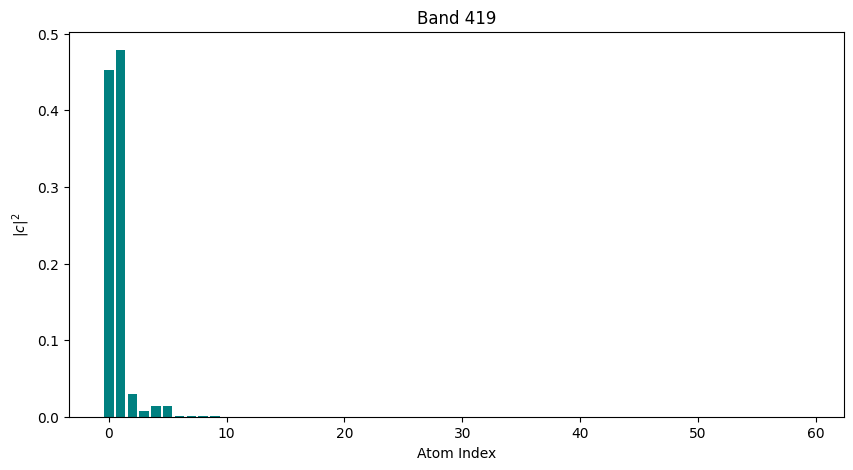

band idx: 420
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -1.18519810e-14+0.00000000e+00j  3.92917261e-03-1.25133232e-03j
 -9.64042146e-02-8.76381725e-02j -1.60961491e-13+1.36395448e-16j
 -4.75356485e-02+1.51343287e-02j -2.84324521e-14+4.97990863e-14j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
 -1.98650482e-02-8.14733582e-05j  2.37176304e-15-7.07643975e-16j
 -8.51281859e-15-8.31063995e-15j -2.40323545e-01-9.65200482e-04j
 -3.19658096e-14+9.68689252e-15j -3.16630101e-01+5.41918576e-01j]


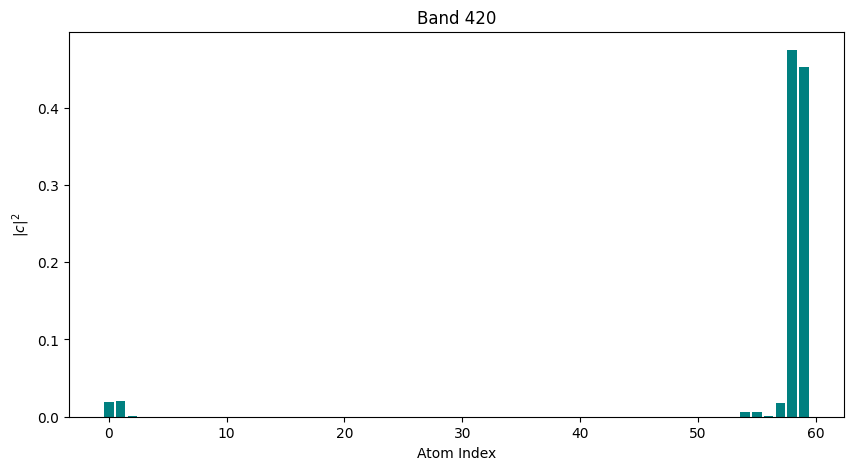

band idx: 421
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -2.50786582e-15+0.00000000e+00j -1.85698311e-02+7.05607213e-03j
  4.86850630e-01+3.96114665e-01j -3.44023596e-14-6.54102313e-16j
  2.24661441e-01-8.53438631e-02j -6.68201802e-15+9.82113696e-15j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
 -4.11831828e-03+2.09008424e-04j -1.10985706e-14+4.10750147e-15j
  4.31050922e-14+3.76378030e-14j -4.98223925e-02+2.53278218e-03j
  1.51093028e-13-5.50549650e-14j -5.94649122e-02+1.15923018e-01j]


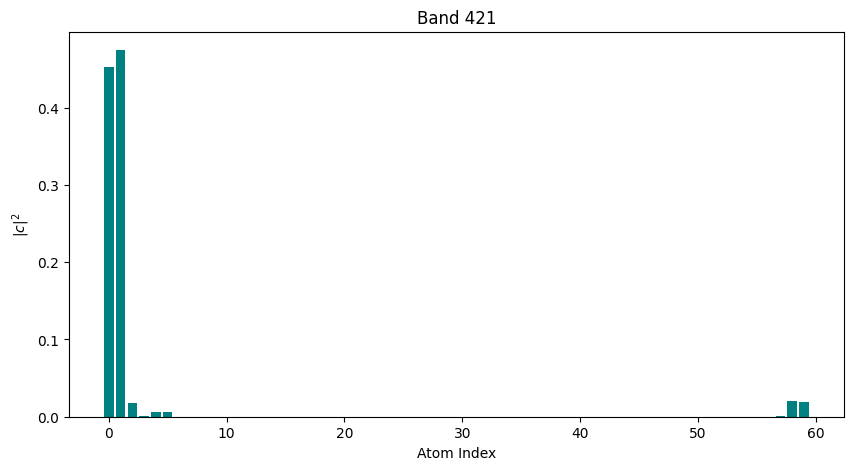

In [18]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band in edge_bands_0:
        k_target = -1.7
    elif band in edge_bands_1:
        k_target = 0.1
    else:
        k_target = 1.7
    if band < min(j_3_2):
        continue
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"band idx: {band}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 
        if i == 0:
            print(atomic_wavefunctions[0])
        elif i == 59:
            print(atomic_wavefunctions[59])

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band}")# at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()

## Case 1

In [19]:
g = results[1].geometry
tb_edge = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

In [20]:
LDOS_0, E_0 = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 6, 
    E_min = -1,
    eta = 0.05
)

LDOS_59, E_59 = invariants.get_local_density_of_states(
    site_idx = 59,
    E_max = 6, 
    E_min = -1,
    eta = 0.05
)

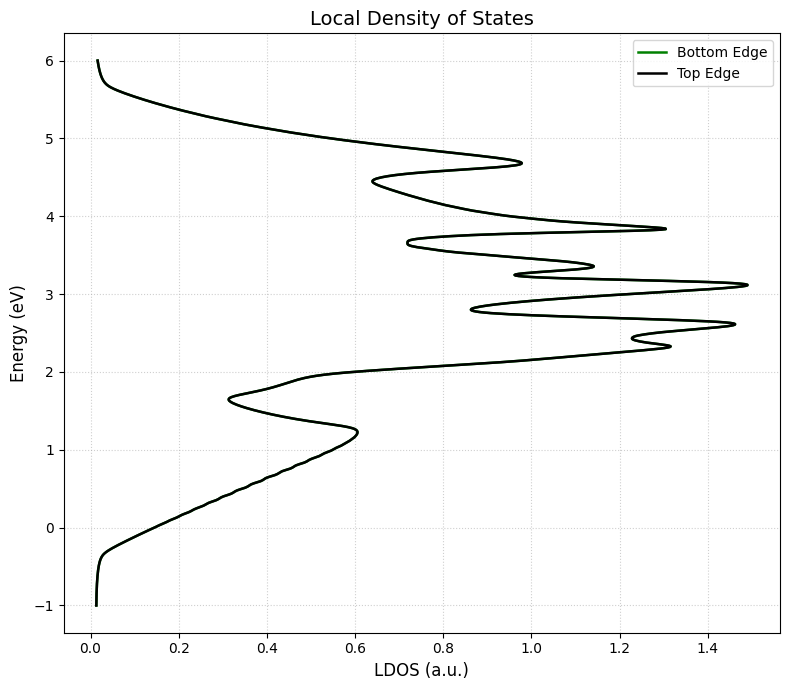

In [21]:
from matplotlib import pyplot as plt
xlabel:str = "LDOS"
figsize: tuple = (8, 7)
fig, ax = plt.subplots(figsize=figsize)
ax.plot(E_0, LDOS_0, color="g", lw=1.8, label=f"Bottom Edge")
ax.plot(E_59, LDOS_59, color="k", lw=1.8, label=f"Top Edge")
ax.set_ylabel("Energy (eV)", fontsize=12)
ax.set_xlabel(f"{xlabel} (a.u.)", fontsize=12)
if xlabel == "LDOS":
    ax.set_title("Local Density of States", fontsize=14)
else:
    ax.set_title("Total Density of States", fontsize=14)
ax.legend(frameon=True)
ax.grid(True, ls=':', alpha=0.6)

plt.tight_layout()
plt.show()

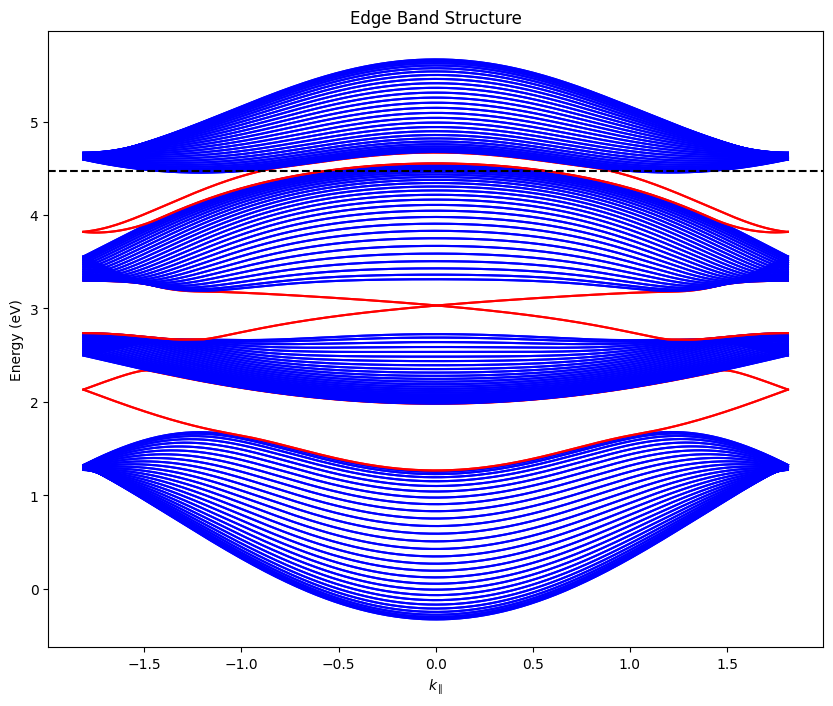

In [22]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=-1.7, threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=1.7, threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands, mu = 4.47)

In [23]:
g.k_edge[-1]

np.float64(1.8137993642342178)

band idx: 298
[0.00000000e+00+0.00000000e+00j 0.00000000e+00+0.00000000e+00j
 1.64766281e-17+0.00000000e+00j 1.76058987e-02-6.48560119e-03j
 5.41813686e-01+4.56651658e-01j 2.47479045e-16+4.58587057e-16j
 1.08105850e-01-3.99177189e-02j 2.13078628e-16+3.80598331e-15j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -5.08847816e-03+2.55436868e-03j  1.88091562e-16+9.30690508e-17j
 -5.33119254e-15-4.13770091e-15j  3.12657162e-02-1.56651318e-02j
  1.04776712e-15+2.60448976e-16j  1.12396591e-02-2.14732001e-01j]


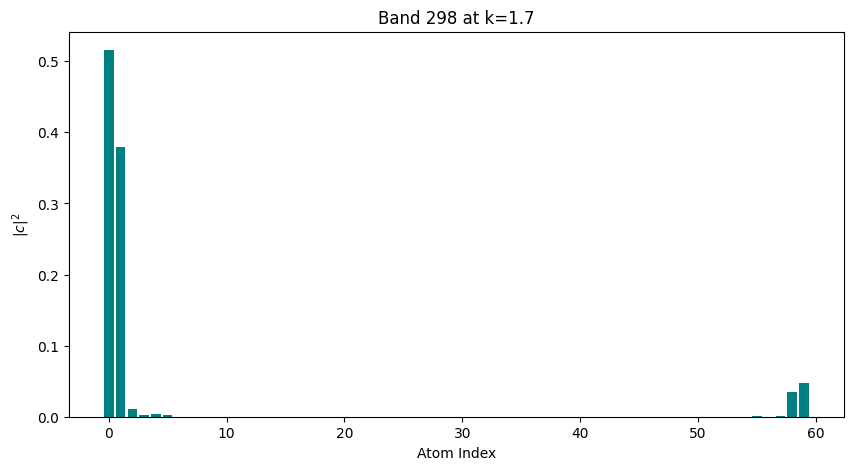

band idx: 299
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  1.76143248e-16+0.00000000e+00j  5.65702915e-03+6.44539019e-04j
  8.45438196e-02+1.97708130e-01j -1.01647223e-15+1.20223419e-16j
  3.47488029e-02+3.93218306e-03j  3.06322440e-15-5.27551093e-15j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  1.87624683e-02+2.17476061e-05j  4.15415638e-17-5.67499002e-18j
 -7.46934573e-16-1.91758449e-15j -1.15239967e-01-2.21829906e-04j
  2.60745372e-16-1.99166620e-17j -3.51277845e-01+6.15383363e-01j]


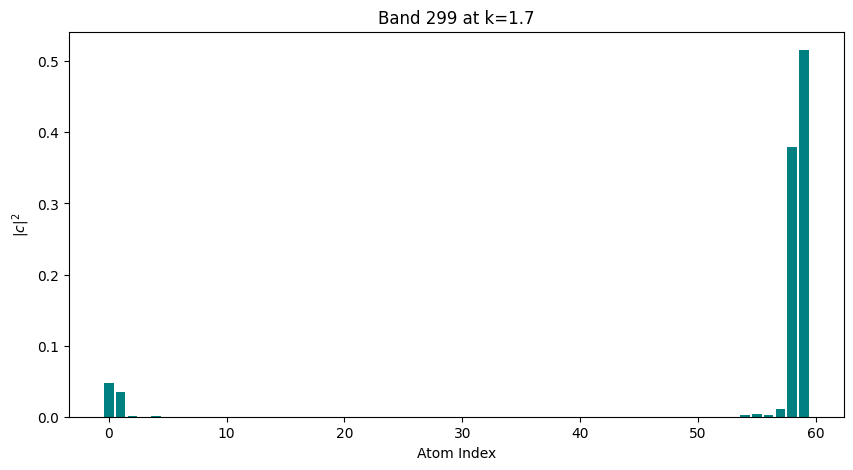

band idx: 300
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -1.52827245e-15+0.00000000e+00j  5.41229902e-15+3.07392560e-16j
 -8.41331615e-14-1.74129642e-13j  1.32462270e-14+3.27410477e-18j
  4.83172832e-14+2.52391814e-15j  1.64574775e-14-2.82730572e-14j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
 -3.77348713e-19+5.06069686e-18j -3.25152771e-02-2.84684452e-03j
 -2.97877098e-01-6.30970202e-01j  9.82538241e-18-1.77142287e-17j
 -2.81903777e-01-2.46163206e-02j -2.15692521e-16-1.09519676e-16j]


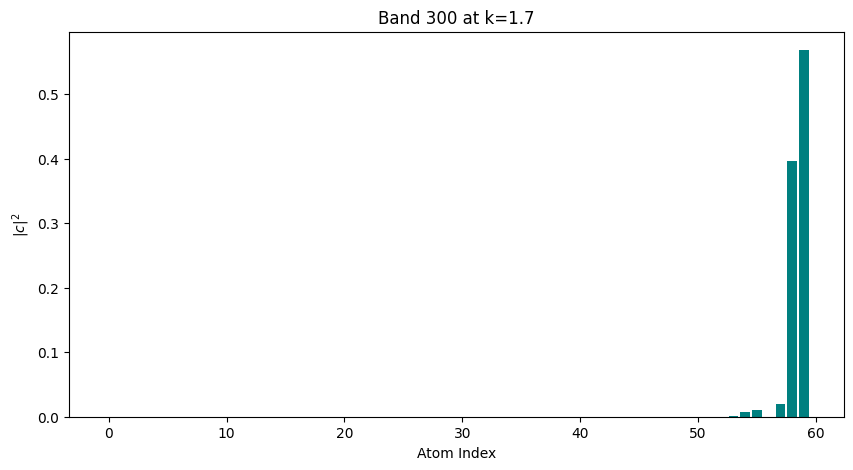

band idx: 301
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -3.26396656e-02+0.00000000e+00j  1.11022302e-16-2.77555756e-17j
 -3.12250226e-16+1.36696210e-15j  2.82976498e-01+6.52499101e-05j
  1.33226763e-15-3.39043346e-16j  3.51775370e-01-6.02584641e-01j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
  5.46862828e-15+1.55780822e-16j  1.52244826e-15+1.33296526e-16j
  1.39473660e-14+2.95436352e-14j -4.87727461e-14-1.34423561e-15j
  1.31994543e-14+1.15259896e-15j  9.95074115e-14-1.65679136e-13j]


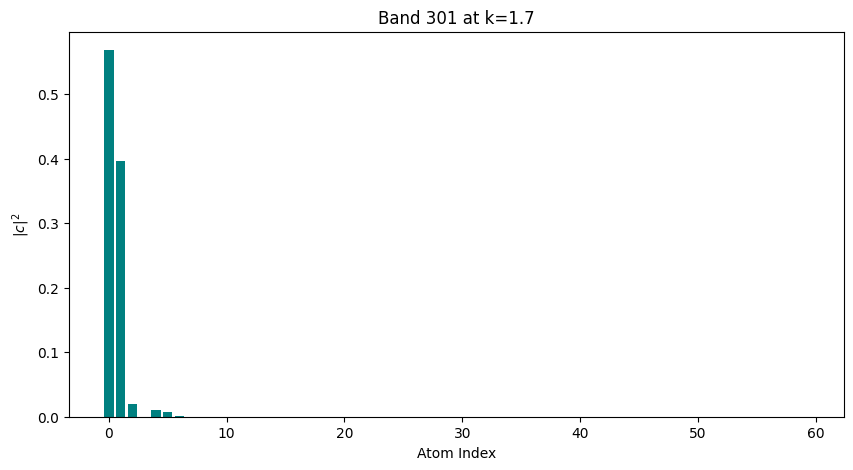

band idx: 358
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -2.25250007e-05+0.00000000e+00j  1.04999882e-04+1.26457510e-04j
 -1.05654611e-03+2.85009638e-03j  6.49056233e-04+5.42464139e-07j
  3.01445240e-03+3.63571751e-03j  2.11253343e-04-3.65161594e-04j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  1.87627804e-07-2.80546501e-09j -1.28295227e-02-1.49895839e-02j
  1.22678834e-01-3.48565967e-01j -5.39116716e-06+8.44292241e-08j
 -3.70042739e-01-4.31614785e-01j -1.68766555e-06+3.03214855e-06j]


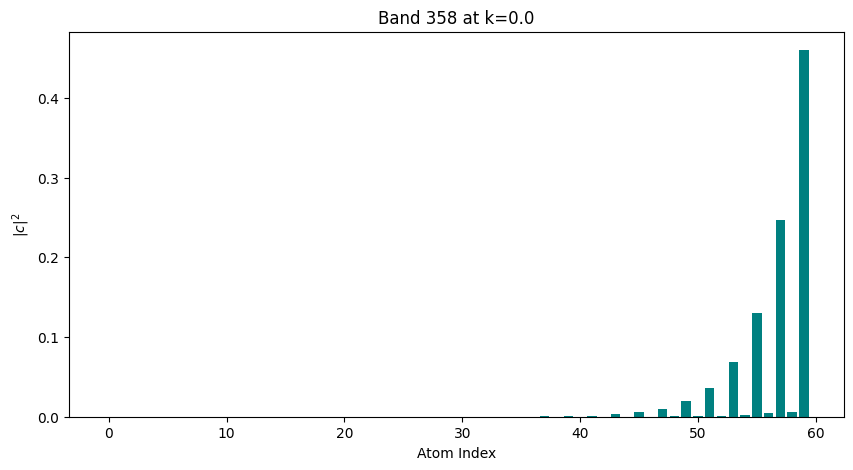

band idx: 359
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -1.97302884e-02+0.00000000e+00j -1.19872672e-07-1.44369683e-07j
  1.20620141e-06-3.25380051e-06j  5.68526803e-01+4.75159758e-04j
 -3.44143686e-06-4.15070156e-06j  1.85042807e-01-3.19855419e-01j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  1.64348527e-04-2.45738646e-06j  1.46467706e-05+1.71127955e-05j
 -1.40055775e-04+3.97938870e-04j -4.72227655e-03+7.39539548e-05j
  4.22457736e-04+4.92751204e-04j -1.47827422e-03+2.65594510e-03j]


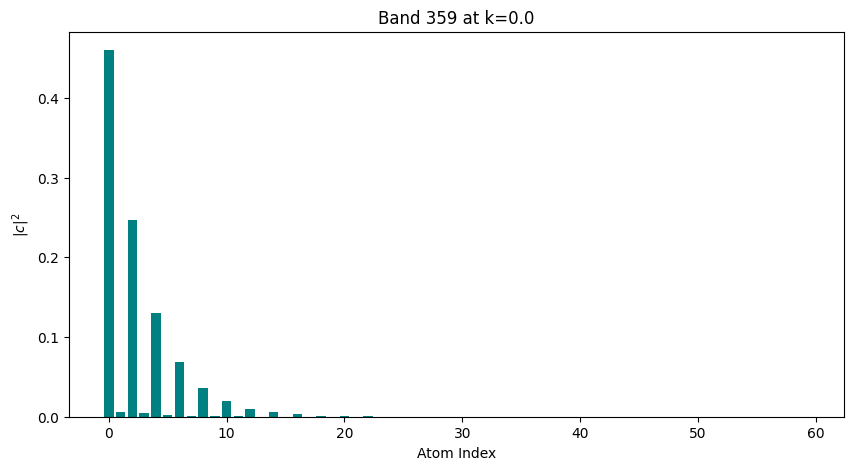

band idx: 360
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  1.35717388e-04+0.00000000e+00j  9.52159131e-04-1.11139959e-02j
  1.88333918e-01-8.80617845e-02j -3.93087170e-03-3.31553287e-06j
  2.77300144e-02-3.20977484e-01j -1.28281603e-03+2.21740587e-03j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
  1.62568886e-02-2.40750592e-04j  6.57343235e-06-9.28803216e-05j
  1.57964929e-03-7.70515845e-04j -4.69530463e-01+7.28914763e-03j
  1.88121595e-04-2.69031425e-03j -1.47414537e-01+2.64761873e-01j]


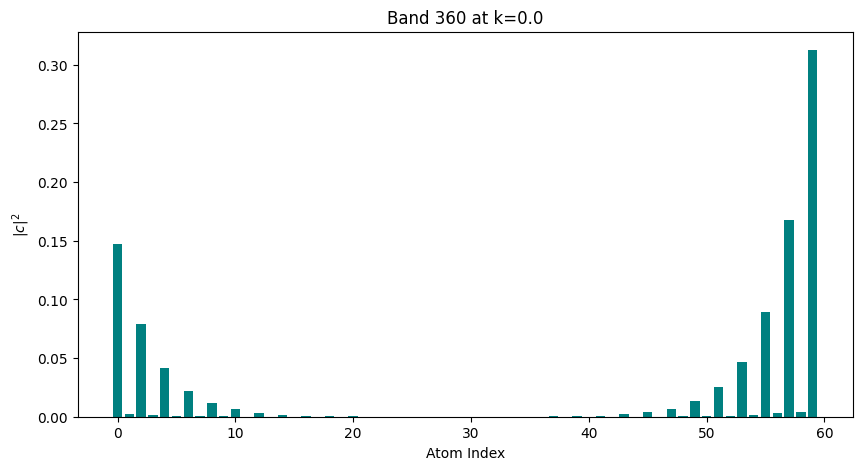

band idx: 361
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  9.31126423e-05+0.00000000e+00j -1.38783034e-03+1.61993307e-02j
 -2.74508238e-01+1.28355453e-01j -2.69688252e-03-2.27471241e-06j
 -4.04181969e-02+4.67844372e-01j -8.80111177e-04+1.52131222e-03j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
  1.11534850e-02-1.65173557e-04j -9.58118088e-06+1.35378766e-04j
 -2.30243573e-03+1.12307411e-03j -3.22134273e-01+5.00091999e-03j
 -2.74198764e-04+3.92129804e-03j -1.01137793e-01+1.81647156e-01j]


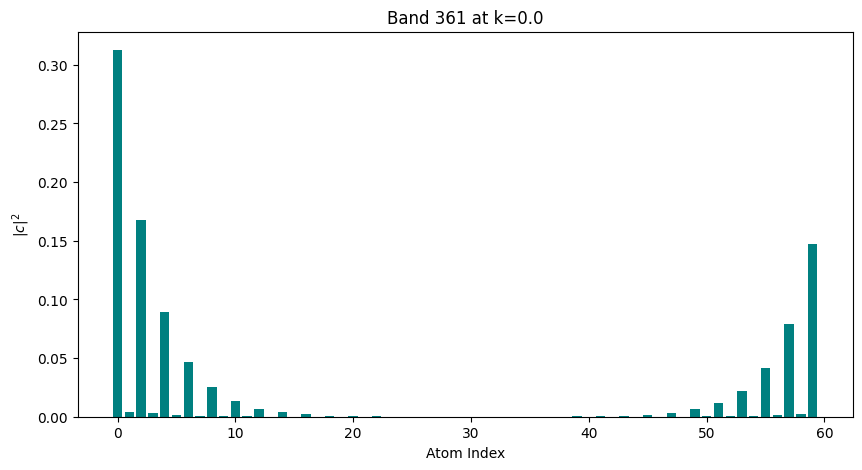

band idx: 418
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  1.99967846e-02+0.00000000e+00j -1.11022302e-16+1.21430643e-16j
  5.24580379e-15+1.33552024e-15j  5.96842302e-01-4.13968197e-05j
  2.16493490e-15-2.77169674e-15j  1.57453584e-01-2.74955750e-01j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -4.26709063e-11-2.87969500e-13j  1.66277078e-11-1.52876072e-11j
 -3.41130229e-10-1.08257170e-10j -1.08189636e-09-7.12757287e-12j
 -4.96317406e-10+4.56253470e-10j -5.84926478e-10+9.90833704e-10j]


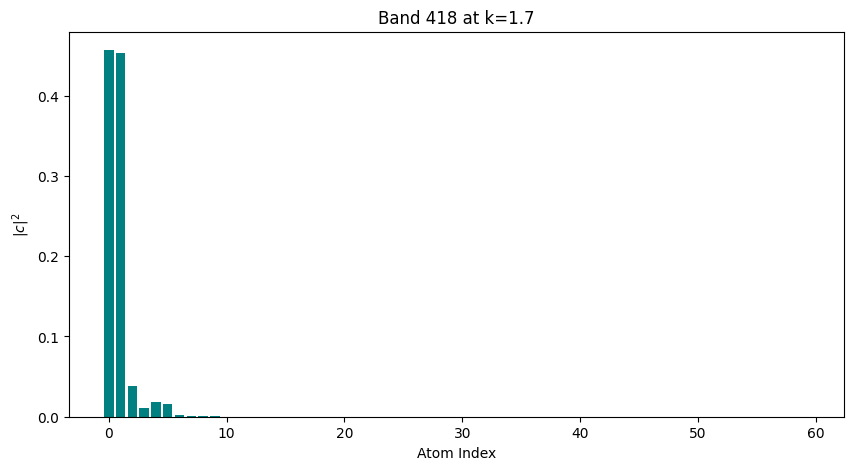

band idx: 419
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -2.25874213e-11+0.00000000e+00j -3.12172378e-11+2.90925077e-11j
  1.10120924e-09+3.33509837e-10j -6.74164885e-10+4.67915046e-14j
  7.91612542e-10-7.37496398e-10j -1.77852138e-10+3.10576770e-10j]
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -2.85601755e-18+2.43429077e-19j  1.47206131e-02-1.35342138e-02j
 -3.02004714e-01-9.58407461e-02j  3.99620814e-16+9.38495620e-17j
 -4.39392887e-01+4.03924035e-01j -1.43498146e-16+2.30386679e-16j]


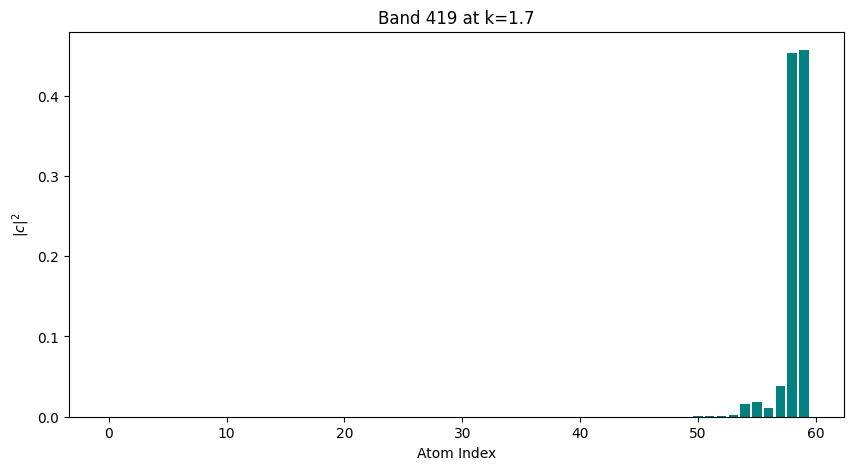

band idx: 420
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  2.22420923e-12+0.00000000e+00j -6.56019874e-03-9.43088302e-03j
 -1.72016642e-01+3.68890530e-01j  5.79444967e-11-1.71157072e-15j
  1.42343524e-01+2.04773813e-01j  1.04652154e-11-1.82912123e-11j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
  1.02669238e-02+7.34703375e-05j -1.40659352e-12-2.05302450e-12j
 -1.02645969e-11+2.12274803e-11j  2.22876957e-01+1.52242274e-03j
  3.66426564e-11+5.34857459e-11j  1.85102334e-01-3.13150671e-01j]


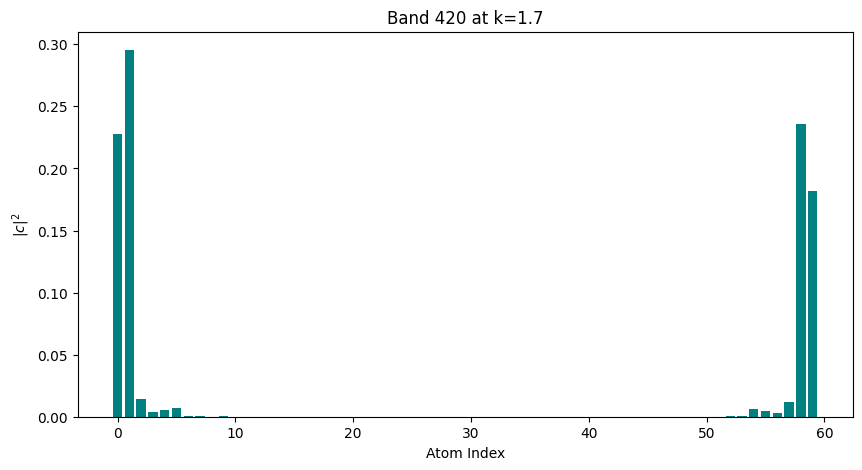

band idx: 421
[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
 -2.48865799e-12+0.00000000e+00j -5.86395501e-03-8.42787961e-03j
 -1.53696255e-01+3.29702408e-01j -6.48327443e-11-5.96237547e-17j
  1.27236407e-01+1.82995498e-01j -1.17115196e-11+2.04644799e-11j]
[ 0.00000000e+00-0.00000000e+00j  0.00000000e+00-0.00000000e+00j
 -1.14878728e-02-8.08722635e-05j -1.25729168e-12-1.83468538e-12j
 -9.17152410e-12+1.89724769e-11j -2.49381614e-01-1.67448515e-03j
  3.27537698e-11+4.77974479e-11j -2.07073923e-01+3.50414524e-01j]


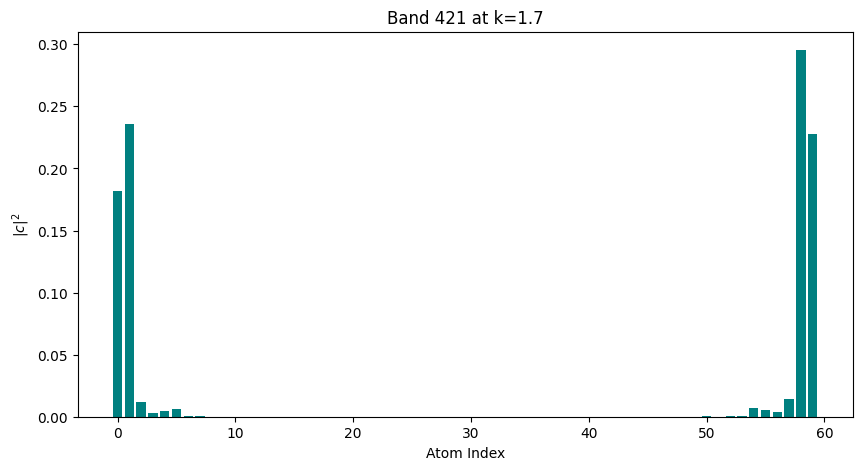

In [24]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band in edge_bands_0:
        k_target = -1.7
    elif band in edge_bands_1:
        k_target = 0.0
    else:
        k_target = 1.7
    if band < min(j_3_2):
        continue
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"band idx: {band}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 
        if i == 0:
            print(atomic_wavefunctions[0])
        elif i == 59:
            print(atomic_wavefunctions[59]) 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()